# Quickstart: GFS vs ECMWF AIFS heating degree days at BNA - dynamical.org Zarr

**Same pipeline, two forecast models.** This notebook computes Heating Degree Days (HDD) at Nashville International Airport (BNA) from NOAA GFS and ECMWF AIFS forecasts, then compares both against hourly ASOS observations. The whole point: HDD is a deterministic transform of temperature — no training, no tuning. Swap the forecast input, get a better result, zero code change.

Datasets used:
- [NOAA GFS forecast](https://dynamical.org/catalog/noaa-gfs-forecast/)
- [ECMWF AIFS Single forecast](https://dynamical.org/catalog/ecmwf-aifs-single-forecast/)
- [ASOS Parquet](https://dynamical.org/catalog/asos-parquet/) — hourly global airport observations

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install -q "xarray[complete]>=2025.3.0" "zarr>=3.0.8" duckdb requests aiohttp

In [2]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

## 1. Load GFS and plot a forecast at BNA

Open the NOAA GFS forecast Zarr store and plot the 2-meter temperature forecast initialized on 2026-01-20 00Z at Nashville International (BNA, 36.12°N, 86.69°W). The `x="valid_time"` argument renders the lead-time axis as wall-clock time.

In [3]:
gfs_ds = xr.open_zarr(
    "https://data.dynamical.org/noaa/gfs/forecast/latest.zarr?email=optional@email.com",
    chunks=None,
)
gfs_ds

<xarray.Dataset> Size: 132TB
Dimensions:                                     (init_time: 7239,
                                                 lead_time: 209, latitude: 721,
                                                 longitude: 1440)
Coordinates:
    expected_forecast_length                    (init_time) timedelta64[ns] 58kB ...
    ingested_forecast_length                    (init_time) timedelta64[ns] 58kB ...
  * init_time                                   (init_time) datetime64[ns] 58kB ...
  * latitude                                    (latitude) float64 6kB 90.0 ....
  * lead_time                                   (lead_time) timedelta64[ns] 2kB ...
  * longitude                                   (longitude) float64 12kB -180...
    spatial_ref                                 int64 8B ...
    valid_time                                  (init_time, lead_time) datetime64[ns] 12MB ...
Data variables: (12/21)
    categorical_freezing_rain_surface           (init_time, lead_time, latitude, longitude) float32 6TB ...
    categorical_ice_pellets_surface             (init_time, lead_time, latitude, longitude) float32 6TB ...
    categorical_rain_surface                    (init_time, lead_time, latitude, longitude) float32 6TB ...
    categorical_snow_surface                    (init_time, lead_time, latitude, longitude) float32 6TB ...
    downward_long_wave_radiation_flux_surface   (init_time, lead_time, latitude, longitude) float32 6TB ...
    downward_short_wave_radiation_flux_surface  (init_time, lead_time, latitude, longitude) float32 6TB ...
    ...                                          ...
    temperature_2m                              (init_time, lead_time, latitude, longitude) float32 6TB ...
    total_cloud_cover_atmosphere                (init_time, lead_time, latitude, longitude) float32 6TB ...
    wind_u_100m                                 (init_time, lead_time, latitude, longitude) float32 6TB ...
    wind_u_10m                                  (init_time, lead_time, latitude, longitude) float32 6TB ...
    wind_v_100m                                 (init_time, lead_time, latitude, longitude) float32 6TB ...
    wind_v_10m                                  (init_time, lead_time, latitude, longitude) float32 6TB ...
Attributes:
    dataset_id:           noaa-gfs-forecast
    dataset_version:      0.2.7
    name:                 NOAA GFS forecast
    description:          Weather forecasts from the Global Forecast System (...
    attribution:          NOAA NWS NCEP GFS data processed by dynamical.org f...
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2021-05-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-384 hours (0-16 days) ahead
    forecast_resolution:  Forecast step 0-120 hours: hourly, 123-384 hours: 3...

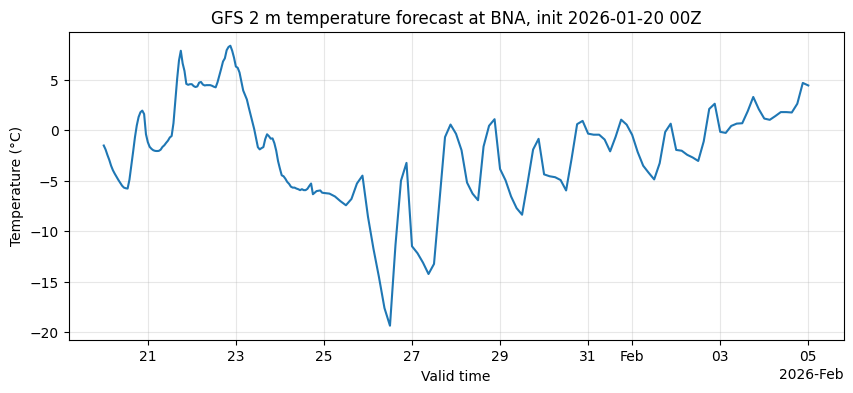

In [4]:
BNA_LAT = 36.119
BNA_LON = -86.689

gfs_bna = gfs_ds["temperature_2m"].sel(
    init_time="2026-01-20T00",
    latitude=BNA_LAT,
    longitude=BNA_LON,
    method="nearest",
)

fig, ax = plt.subplots(figsize=(10, 4))
gfs_bna.plot(x="valid_time", ax=ax)
ax.set_title("GFS 2 m temperature forecast at BNA, init 2026-01-20 00Z")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)

## 2. Load AIFS and plot the same forecast at BNA

ECMWF's Artificial Intelligence Forecasting System (AIFS Single) is a deep-learning weather model. Despite completely different internals, the dataset schema is **identical** to GFS on dynamical.org — same dimension names, same variable names, same coordinate layout. The selection code below is a copy of the GFS cell with only the dataset variable renamed.

In [5]:
aifs_ds = xr.open_zarr(
    "https://data.dynamical.org/ecmwf/aifs-single/forecast/latest.zarr",
    chunks=None,
)
aifs_ds

<xarray.Dataset> Size: 13TB
Dimensions:                                     (init_time: 2975,
                                                 lead_time: 61, latitude: 721,
                                                 longitude: 1440)
Coordinates:
    expected_forecast_length                    (init_time) timedelta64[ns] 24kB ...
    ingested_forecast_length                    (init_time) timedelta64[ns] 24kB ...
  * init_time                                   (init_time) datetime64[ns] 24kB ...
  * latitude                                    (latitude) float64 6kB 90.0 ....
  * lead_time                                   (lead_time) timedelta64[ns] 488B ...
  * longitude                                   (longitude) float64 12kB -180...
    spatial_ref                                 int64 8B ...
    valid_time                                  (init_time, lead_time) datetime64[ns] 1MB ...
Data variables: (12/17)
    dew_point_temperature_2m                    (init_time, lead_time, latitude, longitude) float32 754GB ...
    downward_long_wave_radiation_flux_surface   (init_time, lead_time, latitude, longitude) float32 754GB ...
    downward_short_wave_radiation_flux_surface  (init_time, lead_time, latitude, longitude) float32 754GB ...
    geopotential_height_500hpa                  (init_time, lead_time, latitude, longitude) float32 754GB ...
    geopotential_height_850hpa                  (init_time, lead_time, latitude, longitude) float32 754GB ...
    geopotential_height_925hpa                  (init_time, lead_time, latitude, longitude) float32 754GB ...
    ...                                          ...
    temperature_925hpa                          (init_time, lead_time, latitude, longitude) float32 754GB ...
    total_cloud_cover_atmosphere                (init_time, lead_time, latitude, longitude) float32 754GB ...
    wind_u_100m                                 (init_time, lead_time, latitude, longitude) float32 754GB ...
    wind_u_10m                                  (init_time, lead_time, latitude, longitude) float32 754GB ...
    wind_v_100m                                 (init_time, lead_time, latitude, longitude) float32 754GB ...
    wind_v_10m                                  (init_time, lead_time, latitude, longitude) float32 754GB ...
Attributes:
    dataset_id:           ecmwf-aifs-single-forecast
    dataset_version:      0.1.0
    name:                 ECMWF AIFS Single forecast
    description:          Weather forecasts from the ECMWF Artificial Intelli...
    attribution:          ECMWF AIFS Single forecast data processed by dynami...
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2024-04-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-360 hours (0-15 days) ahead
    forecast_resolution:  6 hourly

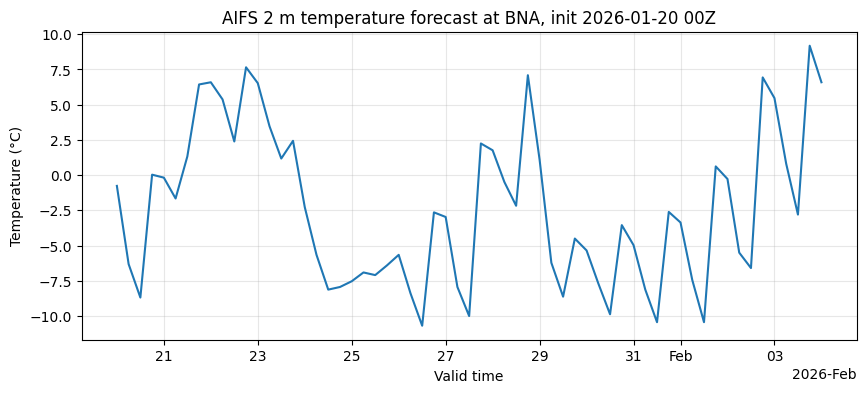

In [6]:
aifs_bna = aifs_ds["temperature_2m"].sel(
    init_time="2026-01-20T00",
    latitude=BNA_LAT,
    longitude=BNA_LON,
    method="nearest",
)

fig, ax = plt.subplots(figsize=(10, 4))
aifs_bna.plot(x="valid_time", ax=ax)
ax.set_title("AIFS 2 m temperature forecast at BNA, init 2026-01-20 00Z")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)

## 3. HDD analysis function

**Heating Degree Days (HDD)** measure how cold a day is relative to a 65 °F (18.333 °C) base — the threshold below which buildings typically need heating. The canonical definition is

$$\mathrm{HDD} = \max(0,\; T_{\text{base}} - T_{\text{avg}}) \quad\text{where}\quad T_{\text{avg}} = (T_{\max} + T_{\min}) / 2$$

HDD is a deterministic function of temperature, so any improvement in forecast temperature propagates directly into an improvement in forecast HDD — no model, no training, just math.

Below we:
1. Pull hourly ASOS observations for BNA and compute observed HDD as the ground truth.
2. Define a single `hdd_analysis` function that works on **any** dataset exposing `temperature_2m(init_time, lead_time, latitude, longitude)` — i.e. both GFS and AIFS unchanged.
3. Compute forecast HDD at 1-day, 3-day, and 5-day lead.

In [7]:
STATION = "BNA"
START = "2025-12-01"
END = "2026-03-01"
HDD_BASE_C = (65 - 32) * 5 / 9  # 18.333 °C
LEADS_DAYS = [1, 3, 5]


def load_station_obs(station: str, start: str, end: str) -> tuple[float, float, pd.Series]:
    """Hourly tmpc from asos-parquet for one ICAO station over [start, end]."""
    base = "https://data.source.coop/dynamical/asos-parquet"
    years = sorted({int(start[:4]), int(end[:4])})
    urls = [f"{base}/year={y}/data.parquet" for y in years]
    df = duckdb.execute(
        """
        SELECT valid, tmpc, latitude, longitude
        FROM read_parquet(?, hive_partitioning=true)
        WHERE station = ?
          AND valid BETWEEN ? AND ?
          AND tmpc IS NOT NULL
        ORDER BY valid
        """,
        [urls, station, start, end],
    ).fetchdf()
    lat = float(df["latitude"].iloc[0])
    lon = float(df["longitude"].iloc[0])
    obs = pd.Series(
        df["tmpc"].to_numpy(dtype=float),
        index=pd.DatetimeIndex(pd.to_datetime(df["valid"], utc=True))
            .tz_convert("UTC").tz_localize(None),
        name="tmpc",
    )
    return lat, lon, obs


station_lat, station_lon, obs = load_station_obs(STATION, START, END)
print(f"{STATION}: ({station_lat:.3f}, {station_lon:.3f}), {len(obs)} hourly obs")

BNA: (36.119, -86.689), 2368 hourly obs


In [8]:
def daily_hdd_from_subdaily(t: pd.Series) -> pd.Series:
    """Daily HDD from sub-daily temperature samples."""
    daily = t.resample("1D").agg(["max", "min"]).dropna()
    t_avg = (daily["max"] + daily["min"]) / 2
    return (HDD_BASE_C - t_avg).clip(lower=0)


obs_hdd = daily_hdd_from_subdaily(obs)
target_days = obs_hdd.index
print(f"Observed HDD: {len(obs_hdd)} days, sum={obs_hdd.sum():.0f}, max={obs_hdd.max():.1f}")
obs_hdd.head()

Observed HDD: 91 days, sum=1082, max=27.5


valid
2025-12-01    16.943333
2025-12-02    16.943333
2025-12-03    17.778333
2025-12-04    16.668333
2025-12-05    16.668333
Freq: D, dtype: float64

In [9]:
def hdd_analysis(
    ds: xr.Dataset,
    station_lat: float,
    station_lon: float,
    target_days: pd.DatetimeIndex,
) -> pd.DataFrame:
    """Forecast HDD at a point for each lead in LEADS_DAYS.

    For each target day D and lead L (in days), uses init_time D-L at 00Z
    and lead_times [24L, 24L+6, 24L+12, 24L+18] h (four 6-hourly samples
    spanning day D). Computes T_avg = (T_max + T_min) / 2 per day, then HDD.

    The dataset is only required to expose ``temperature_2m`` on
    ``(init_time, lead_time, latitude, longitude)`` — works unchanged for
    GFS and AIFS.
    """
    max_lead = max(LEADS_DAYS)
    init_min = (target_days - pd.Timedelta(days=max_lead))[0]
    init_max = target_days[-1]
    t2m_point = (
        ds["temperature_2m"]
        .sel(init_time=slice(init_min, init_max))
        .sel(latitude=station_lat, longitude=station_lon, method="nearest")
        .load()
    )

    columns = {}
    for lead_days in LEADS_DAYS:
        init_times = target_days - pd.Timedelta(days=lead_days)
        base_hours = 24 * lead_days
        leads = pd.to_timedelta([base_hours + h for h in (0, 6, 12, 18)], unit="h")
        sub = t2m_point.sel(lead_time=leads).reindex(init_time=init_times)
        arr = np.asarray(sub.values, dtype=float)
        with np.errstate(all="ignore"):
            t_max = np.nanmax(arr, axis=1)
            t_min = np.nanmin(arr, axis=1)
        t_avg = (t_max + t_min) / 2
        columns[f"{lead_days}d"] = np.clip(HDD_BASE_C - t_avg, 0, None)
    return pd.DataFrame(columns, index=target_days)

## 4. Run the analysis on GFS

In [10]:
gfs_hdd = hdd_analysis(gfs_ds, station_lat, station_lon, target_days)
gfs_hdd.head()

,1d,3d,5d
valid,,,
2025-12-01,16.630208,15.708333,17.011068
2025-12-02,16.227865,14.048177,14.704427
2025-12-03,16.419271,15.848958,15.723958
2025-12-04,14.505208,13.458333,10.145833
2025-12-05,14.872396,15.028646,14.661458


## 5. Run the analysis on AIFS

**Same function, different dataset.** This is the whole trick. Every line of `hdd_analysis` above is indifferent to which forecast model produced the data — both datasets share dimension and variable names, so the selection code, the lead-time math, and the HDD computation are all literally identical.

In [11]:
aifs_hdd = hdd_analysis(aifs_ds, station_lat, station_lon, target_days)
aifs_hdd.head()

,1d,3d,5d
valid,,,
2025-12-01,18.075521,19.009115,19.667318
2025-12-02,16.087240,16.360677,15.763021
2025-12-03,18.360677,17.649740,16.473958
2025-12-04,16.739583,15.462240,15.871419
2025-12-05,16.501302,16.835286,13.716146


## 6. Compare performance

Compute RMSE, MAE, and bias of each model's HDD forecast against observed HDD, at each lead time. Then plot the three series per lead side-by-side.

In [12]:
def metrics(forecast_hdd: pd.DataFrame, obs_hdd: pd.Series) -> pd.DataFrame:
    rows = []
    for lead in forecast_hdd.columns:
        aligned = pd.concat({"obs": obs_hdd, "fc": forecast_hdd[lead]}, axis=1).dropna()
        err = aligned["fc"] - aligned["obs"]
        rows.append({
            "lead": lead,
            "n": len(aligned),
            "RMSE": float(np.sqrt((err**2).mean())),
            "MAE": float(err.abs().mean()),
            "bias": float(err.mean()),
        })
    return pd.DataFrame(rows).set_index("lead")


gfs_metrics = metrics(gfs_hdd, obs_hdd)
aifs_metrics = metrics(aifs_hdd, obs_hdd)
comparison = pd.concat({"GFS": gfs_metrics, "AIFS": aifs_metrics}, axis=1)
comparison.round(2)

GFS                   AIFS                  
       n  RMSE   MAE  bias    n  RMSE   MAE  bias
lead                                             
1d    91  1.80  1.36  0.91   91  1.31  1.05  0.43
3d    91  2.17  1.66  0.93   91  1.65  1.31  0.66
5d    91  3.41  2.68  1.36   91  2.42  1.83  0.65

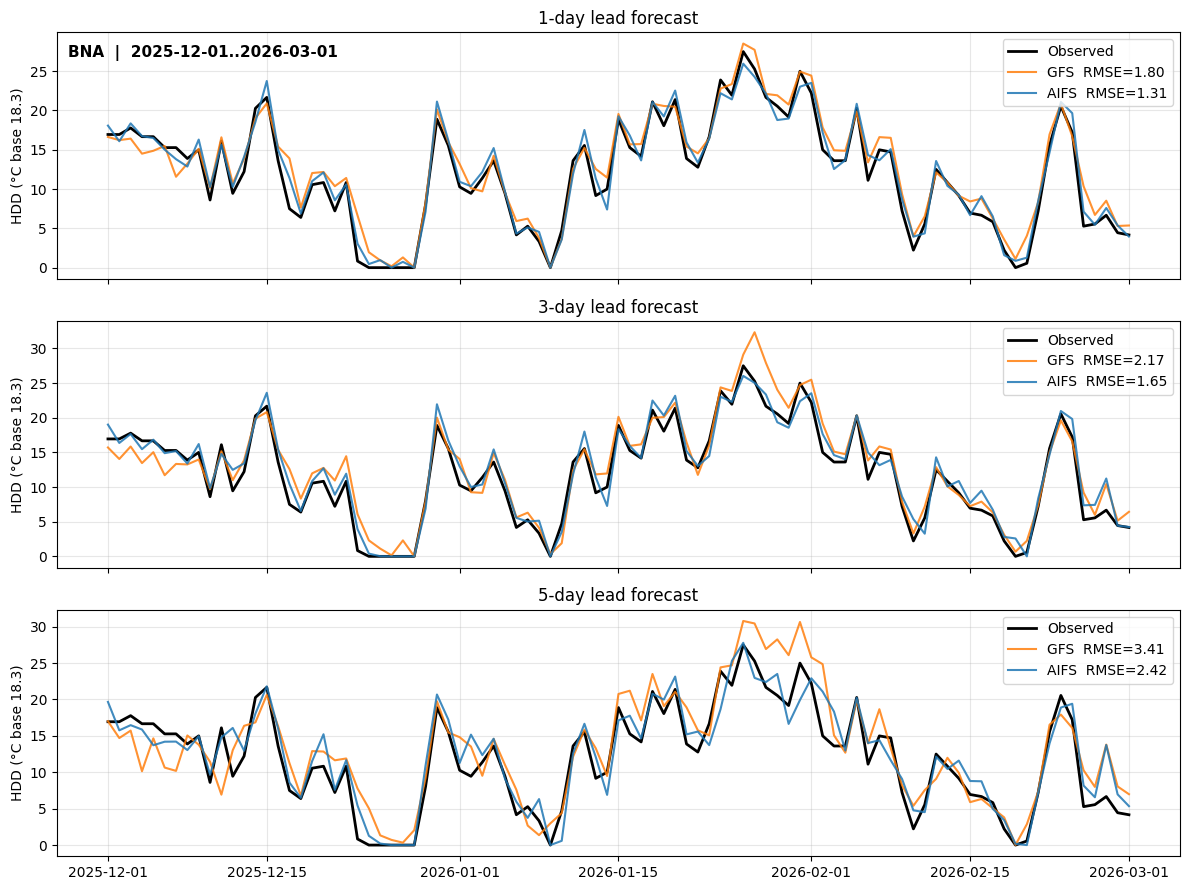

In [13]:
fig, axes = plt.subplots(len(LEADS_DAYS), 1, figsize=(12, 3 * len(LEADS_DAYS)), sharex=True)
for ax, lead_days in zip(axes, LEADS_DAYS):
    col = f"{lead_days}d"
    ax.plot(obs_hdd.index, obs_hdd.values, label="Observed", color="black", lw=2)
    ax.plot(
        gfs_hdd.index, gfs_hdd[col],
        label=f"GFS  RMSE={gfs_metrics.loc[col, 'RMSE']:.2f}",
        color="tab:orange", alpha=0.85,
    )
    ax.plot(
        aifs_hdd.index, aifs_hdd[col],
        label=f"AIFS  RMSE={aifs_metrics.loc[col, 'RMSE']:.2f}",
        color="tab:blue", alpha=0.85,
    )
    ax.set_ylabel("HDD (°C base 18.3)")
    ax.set_title(f"{lead_days}-day lead forecast")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
axes[0].text(
    0.01, 0.95,
    f"{STATION}  |  {START}..{END}",
    transform=axes[0].transAxes, fontsize=11, fontweight="bold", va="top",
)
fig.tight_layout()

### What to read from the numbers

- **AIFS beats GFS at every lead** for this station and window on both RMSE and MAE.
- **The gap grows with lead time** — the classic AI-weather advantage. GFS errors scale up faster than AIFS errors do, so AIFS at 5-day lead is roughly as accurate as GFS at 3-day lead.
- **Same function, two datasets.** `hdd_analysis` was never told which model it was running on. That's the whole selling point: because dynamical.org's Zarr stores share a consistent schema, downstream pipelines are model-agnostic and you can hot-swap the forecast input to get a better result with zero code change.